# Week 4：从 BiLSTM 到 Transformer，再到 BERT

**主题：中文不良信息二分类中的模型演进、架构差异与预训练价值**

这份 Notebook 不只是把三种模型依次跑一遍，而是围绕一个问题展开：

> 当任务、数据划分和评价指标保持一致时，循环结构、自注意力结构和大规模预训练分别带来了什么？

我们先用 BiLSTM 建立序列建模基线，再用随机初始化的 Transformer Encoder 隔离“架构变化”的影响，最后微调预训练 BERT，观察“预训练知识”带来的变化。最终目标不是从演示数据中得出性能结论，而是建立一条可替换真实数据、可重复执行、可检查和可扩展的训练流水线。

> **重要边界**：Notebook 内置的 48 条平衡样本只用于验证代码链路。它们规模很小、语言模式明显，不能用于证明任何模型在真实不良信息检测任务中的优劣。


## Notebook 信息与责任记录

| 项目 | 内容 |
|---|---|
| 作者 | **请在下方参数单元格填写** |
| 作者联系方式 | **请填写邮箱或其他长期有效的联系方式** |
| 实验室代码联系人 | **请填写未来可回答代码问题的联系人及联系方式** |
| 分析开始日期 | 2026-07-28 |
| 分析结束日期 | **运行并解释正式实验后填写** |
| 当前整理日期 | 2026-07-28 |
| 原始文件 | `week4_nlp_training.py` |
| 任务 | 中文文本二分类：`0` 为正常信息，`1` 为不良信息 |

### 阅读路线

1. 明确问题与已有不足；
2. 集中设置参数并固定随机性；
3. 读取、检查并划分数据；
4. 建立统一的数据与评价框架；
5. 训练 BiLSTM、Transformer 和 BERT；
6. 比较结果、解释限制并记录依赖；
7. 将 Notebook 纳入版本控制并参数化为流水线。


## 1. 问题、假设与训练意义

三种模型不是彼此孤立的知识点，而是一条逐步控制变量的学习路线。

| 模型 | 主要机制 | 这一步要回答的问题 | 在不良信息检测中的角色 |
|---|---|---|---|
| BiLSTM | 双向循环建模 + 注意力池化 | 顺序递归能否提取上下文线索？ | 传统深度学习基线 |
| 随机初始化 Transformer | 多头自注意力 + 位置编码 | 不使用循环时，全局依赖和并行建模有什么不同？ | 隔离架构影响 |
| 预训练 BERT | Transformer Encoder + 双向预训练 | 性能变化究竟来自架构，还是来自预训练知识？ | 强预训练基线 |

本实验重点观察 Accuracy、Macro-F1 和不良信息类别的 Precision/Recall/F1。只看 Accuracy 可能掩盖少数类识别失败，因此将 **验证集 Macro-F1** 作为选择最佳检查点的依据，测试集只在训练结束后评估一次。

### 预期而非结论

- 小数据下，预训练 BERT 通常更容易得到有意义的表示，但训练成本更高；
- 随机初始化 Transformer 需要更多数据，内置演示集上可能并不优于 BiLSTM；
- 真实检测效果还会受数据质量、标签定义、类别不平衡和分布外样本影响。


## 2. 过程记录：原始方案为何需要完善

下面记录的是从原始代码片段发展到当前流水线时发现的问题和采取的决策。保留这些“未完成尝试”的信息，可以避免未来重复踩坑。

| 原始状态或尝试 | 暴露的问题 | 当前处理 |
|---|---|---|
| 标题为“RNN → Transformer → BERT”，只有 BiLSTM 与 BERT 片段 | 无法区分架构变化与预训练的影响 | 增加随机初始化 Transformer Encoder |
| BiLSTM 注意力直接对所有位置做 softmax | padding 也可能得到注意力权重 | 使用变长序列打包，并在注意力前屏蔽 padding |
| BERT 只定义模型、优化器和调度器 | 没有数据、训练、验证、保存和测试闭环 | 补充完整微调流程与最优检查点重载 |
| 交互探索容易复制训练代码 | 三个模型的评价逻辑可能逐渐不一致 | 把批次训练、评估、指标和保存封装为函数 |
| 内置少量人工样本 | 容易得到看似很高但没有外部效度的结果 | 明确标记为 smoke test；正式实验必须传入真实 CSV |

**尚未开展的探索**：本 Notebook 没有声称比较过不同最大长度、学习率、类别权重策略或随机种子。每次实际尝试后，应在“实验日志”章节补记参数、现象、失败原因和下一步决策。


## 3. 环境与依赖

建议在独立环境中安装以下依赖：

```bash
python -m venv .venv
# Windows
.venv\Scripts\activate
# macOS / Linux
source .venv/bin/activate

pip install "torch>=2.1" "transformers>=4.40,<6" \
            "scikit-learn>=1.3" "numpy>=1.24" \
            "pandas>=2.0" "matplotlib>=3.7" \
            "jupyterlab>=4" "papermill>=2.5" "nbdime>=4"
```

BERT 首次运行会下载 `google-bert/bert-base-chinese`。离线环境可把 `BERT_MODEL` 改为已经下载到本地的模型目录。PyTorch 的安装命令可能因 CUDA 版本而异，应优先使用其官方安装页面生成命令。

依赖版本会在 Notebook 末尾自动输出，便于以后复现。建议同时将这些约束保存为仓库中的 `requirements.txt`。


## 4. 集中参数区

未来换数据或重复实验时，原则上只需要修改下面这个单元格。它带有 `parameters` 标签，可直接被 Papermill 覆盖。

- `DATA_PATH=None`：使用内置演示数据；
- 自定义 CSV 必须包含 `text,label` 两列，标签只能是 `0` 或 `1`；
- 默认训练三种模型。若只想快速检查流程，可改为 `["bilstm"]`；
- BERT 在 CPU 上较慢，正式训练建议使用 CUDA。


In [4]:
# 作者与追踪信息
AUTHOR = "柴彦峰"
AUTHOR_CONTACT = "example@qq.com"
LAB_CODE_CONTACT = "None"

# 数据与输出
DATA_PATH = None
OUTPUT_ROOT = "outputs/week4_notebook"
MODELS_TO_RUN = ["bilstm", "transformer", "bert"]

# 共同参数
SEED = 42
EPOCHS = 3
BATCH_SIZE = 16
MAX_LENGTH = 128
NUM_CLASSES = 2
WEIGHT_DECAY = 0.01
GRADIENT_CLIP = 1.0

# 从零训练模型参数
BASE_LR = 1e-3
BASE_DROPOUT = 0.3

# BERT 微调参数
BERT_MODEL = "google-bert/bert-base-chinese"
BERT_LR = 2e-5
BERT_DROPOUT = 0.1


## 5. 导入依赖并固定运行环境

这一单元格集中导入依赖。若出现 `ModuleNotFoundError`，先按上一节创建并激活独立环境，再重新启动内核。不要在多个未知环境之间反复安装，否则很难复现。


In [5]:
import copy
import csv
import json
import math
import platform
import random
import sys
from collections import Counter
from dataclasses import asdict, dataclass
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
from typing import Any, Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset

PAD_ID, UNK_ID = 0, 1
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"


### 5.1 训练配置、随机性与设备

配置对象使各模型的超参数随结果一同保存。随机种子同时覆盖 Python、NumPy 和 PyTorch；设备选择顺序为 CUDA、Apple MPS、CPU。固定随机性能够提高重复实验的一致性，但不同硬件和底层算子之间仍可能存在微小差异。


In [6]:
@dataclass
class TrainConfig:
    model_name: str
    num_classes: int = NUM_CLASSES
    max_length: int = MAX_LENGTH
    batch_size: int = BATCH_SIZE
    epochs: int = EPOCHS
    learning_rate: float = BASE_LR
    weight_decay: float = WEIGHT_DECAY
    dropout: float = BASE_DROPOUT
    gradient_clip: float = GRADIENT_CLIP
    seed: int = SEED


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def select_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def validate_parameters() -> None:
    if EPOCHS < 1:
        raise ValueError("EPOCHS 必须大于等于 1。")
    if BATCH_SIZE < 1:
        raise ValueError("BATCH_SIZE 必须大于等于 1。")
    if MAX_LENGTH < 2:
        raise ValueError("MAX_LENGTH 必须大于等于 2。")
    if not 0.0 <= BASE_DROPOUT < 1.0:
        raise ValueError("BASE_DROPOUT 必须位于 [0, 1) 区间。")
    if not 0.0 <= BERT_DROPOUT < 1.0:
        raise ValueError("BERT_DROPOUT 必须位于 [0, 1) 区间。")
    if BASE_LR <= 0 or BERT_LR <= 0:
        raise ValueError("学习率必须为正数。")

# 验证参数
validate_parameters()
# 设置随机数种子
set_seed(SEED)
# 选择设备
device = select_device()
# 创建输出目录
output_root = Path(OUTPUT_ROOT)
output_root.mkdir(parents=True, exist_ok=True)
print(f"输出目录：{output_root}")
print(f"Python={platform.python_version()} | PyTorch={torch.__version__} | device={device}")


输出目录：outputs\week4_notebook
Python=3.12.13 | PyTorch=2.13.0+cu132 | device=cuda


## 6. 数据：先验证链路，再替换为真实数据

内置样本刻意保持两类平衡，适合检查读取、划分、训练、验证、保存和绘图是否连通。它不是公开基准，也没有经过独立标注，因此不能用于论文结论。

正式实验应做到：

1. 给出数据来源、许可、采集时间和标签定义；
2. 删除或匿名化个人信息，不在 Notebook 中公开敏感原文；
3. 说明去重、缺失值与冲突标签的处理方式；
4. 若完整数据不可共享，至少提供匿名化样本、字段说明和获取流程；
5. 对数据集版本使用固定文件哈希或 DOI。


In [7]:
DEMO_SAMPLES = [
    ("今天阳光很好，适合去公园散步。", 0),
    ("这部电影的配乐很出色，剧情也很完整。", 0),
    ("请帮我查询明天从北京到上海的高铁。", 0),
    ("学校图书馆周末几点闭馆？", 0),
    ("这份学习计划安排得很合理。", 0),
    ("我想学习如何使用Python处理表格数据。", 0),
    ("今晚和家人一起吃饭，心情很好。", 0),
    ("这款显示器的色彩表现很自然。", 0),
    ("请总结这篇关于人工智能的新闻。", 0),
    ("老师建议我补充实验对比和误差分析。", 0),
    ("这本书对机器学习基础讲得很清楚。", 0),
    ("请将会议时间调整到周五下午。", 0),
    ("这个开源项目的文档写得比较完整。", 0),
    ("我准备使用验证集选择最优模型。", 0),
    ("今天完成了数据清洗和格式检查。", 0),
    ("祝你生日快乐，希望每天都开心。", 0),
    ("这段代码存在一个需要修复的小问题。", 0),
    ("请解释Transformer中的自注意力机制。", 0),
    ("我打算周末复习概率论和线性代数。", 0),
    ("实验结果需要同时报告准确率和F1值。", 0),
    ("请给出一份健康、规律的作息建议。", 0),
    ("这个问题可以先从最简单的基线开始。", 0),
    ("感谢你的帮助，我已经解决了问题。", 0),
    ("模型训练结束后应保存最佳检查点。", 0),
    ("这条留言持续辱骂并贬低某个群体。", 1),
    ("帖子用恶毒词语反复攻击一名同学。", 1),
    ("该内容鼓动大家排斥特定身份的人。", 1),
    ("留言包含明显的人身威胁和恐吓。", 1),
    ("这段文字宣扬以暴力方式报复他人。", 1),
    ("评论恶意传播受害人的隐私信息。", 1),
    ("发帖者使用侮辱性称呼攻击陌生人。", 1),
    ("该消息煽动针对某个群体的仇恨。", 1),
    ("内容以伤害他人为乐并公开炫耀。", 1),
    ("这是一条带有严重歧视意味的评论。", 1),
    ("帖子威胁要在线下伤害对方。", 1),
    ("该用户持续发布骚扰和恐吓信息。", 1),
    ("评论号召他人共同围攻一名用户。", 1),
    ("内容对未成年人进行恶意羞辱。", 1),
    ("这条消息包含针对个人的暴力威胁。", 1),
    ("发帖者鼓励实施危险的报复行为。", 1),
    ("评论用极端言辞贬损特定人群。", 1),
    ("该文本试图煽动群体之间的敌意。", 1),
    ("留言包含持续性的网络霸凌内容。", 1),
    ("帖子公开鼓吹对他人进行恶意伤害。", 1),
    ("该评论传播仇恨并要求排斥他人。", 1),
    ("这段话对受害者进行威胁和羞辱。", 1),
    ("消息以攻击性语言煽动网络围攻。", 1),
    ("内容包含明显的骚扰、辱骂和恐吓。", 1),
]


### 6.1 读取、校验并分层划分

读取函数会检查文件、列名、空文本、标签类型和每类样本数，并在错误发生的行给出可定位的信息。随后以固定随机种子完成 60%/20%/20% 分层划分。


In [8]:
def load_samples(csv_path: str | None) -> List[Tuple[str, int]]:
    """_summary_
    加载样本
    Args:
        csv_path (str | None): CSV 文件路径

    Returns:
        List[Tuple[str, int]]: 加载的样本
    """
    # 演示数据
    if csv_path is None:
        print("未指定 DATA_PATH：使用内置演示数据，仅验证训练链路。")
        return list(DEMO_SAMPLES)

    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(f"找不到数据文件：{path}")

    samples: List[Tuple[str, int]] = []
    with path.open("r", encoding="utf-8-sig", newline="") as file:
        reader = csv.DictReader(file)
        if not reader.fieldnames or not {"text", "label"}.issubset(reader.fieldnames):
            raise ValueError("CSV 必须包含 text、label 两列。")
        for line_no, row in enumerate(reader, start=2):
            text = (row.get("text") or "").strip()
            raw_label = (row.get("label") or "").strip()
            if not text:
                continue
            try:
                label = int(raw_label)
            except ValueError as exc:
                raise ValueError(f"第 {line_no} 行 label 不是整数：{raw_label!r}") from exc
            if label not in (0, 1):
                raise ValueError(f"第 {line_no} 行 label 必须是 0 或 1。")
            samples.append((text, label))

    counts = Counter(label for _, label in samples)
    if len(samples) < 20 or min(counts.values(), default=0) < 5:
        raise ValueError("分层划分要求至少 20 条数据且每类至少 5 条。")
    return samples


def split_samples(samples, seed):
    """
    将样本集按给定种子随机划分为训练集、验证集、测试集。
    """
    texts = [text for text, _ in samples]
    labels = [label for _, label in samples]
    train_x, temp_x, train_y, temp_y = train_test_split(
        texts, labels, test_size=0.4, random_state=seed, stratify=labels
    )
    val_x, test_x, val_y, test_y = train_test_split(
        temp_x, temp_y, test_size=0.5, random_state=seed, stratify=temp_y
    )
    return (
        list(zip(train_x, train_y)),
        list(zip(val_x, val_y)),
        list(zip(test_x, test_y)),
    )

# 加载 + 划分 数据集
samples = load_samples(DATA_PATH)
train_samples, val_samples, test_samples = split_samples(samples, SEED)


未指定 DATA_PATH：使用内置演示数据，仅验证训练链路。


### 6.2 数据质量检查

先检查各划分的规模、类别数量、文本长度和重复项。词表只能从训练集构建，避免让验证集和测试集信息泄漏到训练阶段。


In [ ]:
def summarize_split(name, part):
    
    frame = pd.DataFrame(part, columns=["text", "label"])
    return {
        "split": name,
        "samples": len(frame),
        "class_0": int((frame["label"] == 0).sum()),
        "class_1": int((frame["label"] == 1).sum()),
        "mean_chars": round(frame["text"].str.len().mean(), 2),
        "max_chars": int(frame["text"].str.len().max()),
        "duplicates": int(frame["text"].duplicated().sum()),
    }


split_summary = pd.DataFrame([
    summarize_split("train", train_samples),
    summarize_split("validation", val_samples),
    summarize_split("test", test_samples),
])
display(split_summary)
display(pd.DataFrame(train_samples[:6], columns=["text", "label"]))


,split,samples,class_0,class_1,mean_chars,max_chars,duplicates
0,train,28,14,14,15.64,21,0
1,validation,10,5,5,15.80,23,0
2,test,10,5,5,15.60,18,0


,text,label
0,留言包含持续性的网络霸凌内容。,1
1,帖子用恶毒词语反复攻击一名同学。,1
2,请将会议时间调整到周五下午。,0
3,我想学习如何使用Python处理表格数据。,0
4,消息以攻击性语言煽动网络围攻。,1
5,帖子公开鼓吹对他人进行恶意伤害。,1


**解释**：采用 60%/20%/20% 分层划分，是为了让每部分都保留类别比例。训练集用于拟合参数，验证集用于选择最佳轮次，测试集只用于最终一次评估。正式研究还应按来源、时间或用户划分数据，以避免近重复文本跨集合造成泄漏。


## 7. 字符级输入流水线

BiLSTM 和随机初始化 Transformer 共用同一字符词表与批处理逻辑，使二者差异主要来自模型架构。中文字符级切分简单透明，但它不是 BERT 的 WordPiece 分词，因此三者比较仍需在结论中注明分词差异。


In [ ]:
def build_vocab(train_part, min_freq=1):
    counter = Counter()
    for text, _ in train_part:
        counter.update(char for char in text if not char.isspace())
    vocab = {PAD_TOKEN: PAD_ID, UNK_TOKEN: UNK_ID}
    for char, frequency in sorted(counter.items()):
        if frequency >= min_freq:
            vocab[char] = len(vocab)
    return vocab


class CharTextDataset(Dataset):
    def __init__(self, part, vocab, max_length):
        self.samples = list(part)
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        text, label = self.samples[index]
        ids = [
            self.vocab.get(char, UNK_ID)
            for char in text
            if not char.isspace()
        ][: self.max_length]
        return torch.tensor(ids or [UNK_ID], dtype=torch.long), label


def collate_char_batch(batch):
    sequences, labels = zip(*batch)
    width = max(sequence.size(0) for sequence in sequences)
    input_ids = torch.full((len(sequences), width), PAD_ID, dtype=torch.long)
    attention_mask = torch.zeros_like(input_ids)
    for row, sequence in enumerate(sequences):
        length = sequence.size(0)
        input_ids[row, :length] = sequence
        attention_mask[row, :length] = 1
    return input_ids, attention_mask, torch.tensor(labels, dtype=torch.long)


vocab = build_vocab(train_samples)
print(f"训练集字符词表大小：{len(vocab)}")


训练集字符词表大小：251


### 7.1 构造 DataLoader

训练集启用随机打乱，验证集与测试集保持固定顺序；三个集合共用同一批处理函数。


In [11]:
def make_char_loaders(train_part, val_part, test_part, vocab, config):
    datasets = [
        CharTextDataset(part, vocab, config.max_length)
        for part in (train_part, val_part, test_part)
    ]
    return (
        DataLoader(datasets[0], batch_size=config.batch_size, shuffle=True,
                   collate_fn=collate_char_batch),
        DataLoader(datasets[1], batch_size=config.batch_size, shuffle=False,
                   collate_fn=collate_char_batch),
        DataLoader(datasets[2], batch_size=config.batch_size, shuffle=False,
                   collate_fn=collate_char_batch),
    )


## 8. 模型一：BiLSTM

BiLSTM 从正向和反向读取序列，使每个位置同时拥有左右上下文。随后，注意力池化学习哪些位置对分类更重要。

两个容易被忽略的实现细节：

1. `pack_padded_sequence` 避免 LSTM 把 padding 当作真实内容处理；
2. softmax 前把 padding 的得分设为极小值，避免它们获得注意力权重。


In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self, vocab_size, embed_dim=128, hidden_dim=256,
        num_layers=2, num_classes=2, dropout=0.3
    ):
        super().__init__()
        # 嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        # LSTM（长短期记忆单元）
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        # 注意力层
        self.attention = nn.Linear(hidden_dim * 2, 1)
        # 分类层
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        # 计算嵌入向量
        embedded = self.dropout(self.embedding(input_ids))
        # 计算序列长度
        lengths = attention_mask.sum(dim=1).to("cpu")
        # 将序列填充为相同长度
        packed = pack_padded_sequence(
            embedded, lengths,
            batch_first=True, enforce_sorted=False
        )
        # LSTM输出
        packed_output, _ = self.lstm(packed)
        output, _ = pad_packed_sequence(
            packed_output, batch_first=True, total_length=input_ids.size(1)
        )
        # 计算注意力分数 (B, T, H)
        scores = self.attention(output).squeeze(-1)
        # 填充
        scores = scores.masked_fill(attention_mask.eq(0), -1e4)
        # 计算权重
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        # 计算上下文向量
        context = torch.sum(weights * output, dim=1)
        # 分类
        return self.classifier(self.dropout(context))


## 9. 模型二：随机初始化 Transformer Encoder

Transformer 不按时间步递归，而是让每个位置通过自注意力直接与其他位置交互。由于自注意力本身不知道顺序，需要额外加入位置编码。这里从随机参数开始训练，用它与 BiLSTM 的差异观察“架构影响”；它与预训练 BERT 的差异则帮助观察“预训练影响”。


In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_length, dropout):
        super().__init__()
        position = torch.arange(max_length).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim)
        )
        encoding = torch.zeros(max_length, embed_dim)
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("encoding", encoding.unsqueeze(0), persistent=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, embeddings):
        return self.dropout(
            embeddings + self.encoding[:, : embeddings.size(1)]
        )


class TransformerClassifier(nn.Module):
    def __init__(
        self, vocab_size, max_length, embed_dim=128, num_heads=4,
        feedforward_dim=256, num_layers=2, num_classes=2, dropout=0.3
    ):
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim 必须能被 num_heads 整除。")
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.position = PositionalEncoding(embed_dim, max_length, dropout)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=feedforward_dim, dropout=dropout,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            layer, num_layers=num_layers, norm=nn.LayerNorm(embed_dim)
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        embedded = self.embedding(input_ids) * math.sqrt(
            self.embedding.embedding_dim
        )
        encoded = self.encoder(
            self.position(embedded),
            src_key_padding_mask=attention_mask.eq(0),
        )
        valid = attention_mask.unsqueeze(-1).to(encoded.dtype)
        pooled = (encoded * valid).sum(dim=1)
        pooled = pooled / valid.sum(dim=1).clamp_min(1.0)
        return self.classifier(self.dropout(pooled))


## 10. 统一评价与从零训练流程

为保证比较一致，BiLSTM 和随机初始化 Transformer 共用同一训练、验证和测试函数。训练时使用按类别频率计算的权重，梯度裁剪防止异常大梯度；每轮根据验证集 Macro-F1 选优，最后重载最佳权重。


In [14]:
def balanced_class_weights(part, num_classes, device):
    counts = np.bincount([label for _, label in part], minlength=num_classes)
    if np.any(counts == 0):
        raise ValueError(f"训练集存在空类别：{counts.tolist()}")
    weights = len(part) / (num_classes * counts.astype(np.float32))
    return torch.tensor(weights, dtype=torch.float32, device=device)


def calculate_metrics(labels, predictions):
    accuracy = accuracy_score(labels, predictions)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    pos_p, pos_r, pos_f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", pos_label=1, zero_division=0
    )
    matrix = confusion_matrix(labels, predictions, labels=[0, 1])
    return {
        "accuracy": float(accuracy),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "positive_precision": float(pos_p),
        "positive_recall": float(pos_r),
        "positive_f1": float(pos_f1),
        "confusion_matrix": matrix.tolist(),
    }


def save_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(value, file, ensure_ascii=False, indent=2)


### 10.1 单轮训练/评价与最佳模型选择

`run_char_epoch` 通过是否传入优化器决定训练或评价模式；`fit_char_model` 负责多轮训练、验证选优、测试和保存，从而避免为两种模型复制训练循环。


In [15]:
def run_char_epoch(model, loader, device, class_weights, optimizer=None, clip=1.0):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, labels_all, predictions_all = 0.0, [], []

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for input_ids, attention_mask, labels in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(input_ids, attention_mask)
            loss = F.cross_entropy(logits, labels, weight=class_weights)
            if is_training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            labels_all.extend(labels.cpu().tolist())
            predictions_all.extend(logits.argmax(dim=-1).cpu().tolist())

    mean_loss = total_loss / len(loader.dataset)
    return mean_loss, calculate_metrics(labels_all, predictions_all)


def fit_char_model(model, loaders, train_part, config, device, output_dir, vocab):
    model = model.to(device)
    train_loader, val_loader, test_loader = loaders
    class_weights = balanced_class_weights(train_part, config.num_classes, device)
    optimizer = AdamW(
        model.parameters(), lr=config.learning_rate,
        weight_decay=config.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )
    best_f1, best_state, history = -1.0, None, []

    for epoch in range(1, config.epochs + 1):
        train_loss, _ = run_char_epoch(
            model, train_loader, device, class_weights,
            optimizer=optimizer, clip=config.gradient_clip
        )
        val_loss, val_metrics = run_char_epoch(
            model, val_loader, device, class_weights
        )
        scheduler.step(val_metrics["macro_f1"])
        history.append({
            "epoch": epoch, "train_loss": train_loss,
            "val_loss": val_loss, **val_metrics
        })
        print(
            f"[{config.model_name}] epoch={epoch} "
            f"val_loss={val_loss:.4f} val_macro_f1={val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "config": asdict(config),
    }, output_dir / "best_model.pt")
    test_loss, test_metrics = run_char_epoch(
        model, test_loader, device, class_weights
    )
    result = {
        "model": config.model_name, "best_val_macro_f1": best_f1,
        "test_loss": test_loss, "test_metrics": test_metrics,
        "history": history,
    }
    save_json(output_dir / "metrics.json", result)
    print(f"[{config.model_name}] test_macro_f1={test_metrics['macro_f1']:.4f}")
    return result, model


## 11. 模型三：预训练 BERT

BERT 同样建立在 Transformer Encoder 上，但不是从随机参数开始。预训练阶段已经从大规模文本中学习了语言表示，下游训练只需微调模型和分类头。

本流程使用：

- 动态 padding，减少批次中的无效计算；
- AdamW 参数分组，对 bias 和 LayerNorm 权重不施加权重衰减；
- 前 10% 步数 warmup，之后线性衰减；
- 与前两种模型相同的类别权重、梯度裁剪和评价指标；
- 保存验证集 Macro-F1 最佳的本地检查点，再进行测试。


In [16]:
class BertTextDataset(Dataset):
    def __init__(self, part, tokenizer, max_length):
        self.samples = list(part)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        text, label = self.samples[index]
        encoded = self.tokenizer(
            text, truncation=True, max_length=self.max_length
        )
        encoded["labels"] = label
        return encoded


def make_bert_loaders(train_part, val_part, test_part, tokenizer, config):
    from transformers import DataCollatorWithPadding

    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    datasets = [
        BertTextDataset(part, tokenizer, config.max_length)
        for part in (train_part, val_part, test_part)
    ]
    return (
        DataLoader(datasets[0], batch_size=config.batch_size,
                   shuffle=True, collate_fn=collator),
        DataLoader(datasets[1], batch_size=config.batch_size,
                   shuffle=False, collate_fn=collator),
        DataLoader(datasets[2], batch_size=config.batch_size,
                   shuffle=False, collate_fn=collator),
    )


def move_batch_to_device(batch, device):
    return {name: tensor.to(device) for name, tensor in batch.items()}


### 11.1 BERT 的单轮训练与评价

BERT 与前两种模型复用同一指标计算方式，但批次是一个由分词器字段组成的字典，因此单独封装批次训练函数。


In [17]:
def run_bert_epoch(
    model, loader, device, class_weights,
    optimizer=None, scheduler=None, clip=1.0
):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, labels_all, predictions_all = 0.0, [], []
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for batch in loader:
            batch = move_batch_to_device(batch, device)
            labels = batch.pop("labels")
            if is_training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(**batch).logits
            loss = F.cross_entropy(logits, labels, weight=class_weights)
            if is_training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * labels.size(0)
            labels_all.extend(labels.cpu().tolist())
            predictions_all.extend(logits.argmax(dim=-1).cpu().tolist())

    mean_loss = total_loss / len(loader.dataset)
    return mean_loss, calculate_metrics(labels_all, predictions_all)


### 11.2 BERT 完整微调、选优与重载

最佳检查点保存到本地后，先释放当前模型，再重新载入最佳版本进行测试，避免同时在显存中保留两份 BERT。


In [18]:
def fit_bert(train_part, val_part, test_part, config, device, output_dir, model_name):
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        get_linear_schedule_with_warmup,
    )

    print(f"[bert] 加载预训练模型：{model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=config.num_classes,
        hidden_dropout_prob=config.dropout,
        attention_probs_dropout_prob=config.dropout,
    ).to(device)
    loaders = make_bert_loaders(
        train_part, val_part, test_part, tokenizer, config
    )
    train_loader, val_loader, test_loader = loaders
    class_weights = balanced_class_weights(
        train_part, config.num_classes, device
    )

    no_decay = ("bias", "LayerNorm.weight")
    optimizer_groups = [
        {
            "params": [p for n, p in model.named_parameters()
                       if not any(item in n for item in no_decay)],
            "weight_decay": config.weight_decay,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(item in n for item in no_decay)],
            "weight_decay": 0.0,
        },
    ]
    optimizer = AdamW(optimizer_groups, lr=config.learning_rate)
    total_steps = config.epochs * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    best_f1, history = -1.0, []
    for epoch in range(1, config.epochs + 1):
        train_loss, _ = run_bert_epoch(
            model, train_loader, device, class_weights,
            optimizer=optimizer, scheduler=scheduler,
            clip=config.gradient_clip
        )
        val_loss, val_metrics = run_bert_epoch(
            model, val_loader, device, class_weights
        )
        history.append({
            "epoch": epoch, "train_loss": train_loss,
            "val_loss": val_loss, **val_metrics
        })
        print(
            f"[bert] epoch={epoch} val_loss={val_loss:.4f} "
            f"val_macro_f1={val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            model.save_pretrained(output_dir)
            tokenizer.save_pretrained(output_dir)

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    best_model = AutoModelForSequenceClassification.from_pretrained(
        output_dir, local_files_only=True
    ).to(device)
    test_loss, test_metrics = run_bert_epoch(
        best_model, test_loader, device, class_weights
    )
    result = {
        "model": "bert", "pretrained_model": model_name,
        "best_val_macro_f1": best_f1, "test_loss": test_loss,
        "test_metrics": test_metrics, "history": history,
    }
    save_json(output_dir / "metrics.json", result)
    print(f"[bert] test_macro_f1={test_metrics['macro_f1']:.4f}")
    return result, best_model, tokenizer


## 12. 运行实验

下面的调度单元格把前面的模块连接成完整流水线。每个模型开始前重新设置相同随机种子；所有结果保存在 `OUTPUT_ROOT` 中。

运行前请再次确认：

- 只做代码检查：可把 `MODELS_TO_RUN` 改为 `["bilstm"]`，并令 `EPOCHS=1`；
- 做完整对比：保留三种模型，并使用真实数据；
- 论文级比较：至少重复多个随机种子并报告均值与标准差，不能只挑最好的一次。


In [19]:
requested = set(MODELS_TO_RUN)
allowed = {"bilstm", "transformer", "bert"}
unknown = requested - allowed
if unknown:
    raise ValueError(f"未知模型：{sorted(unknown)}；允许值为 {sorted(allowed)}")

results = []
trained_objects = {}

for model_name in MODELS_TO_RUN:
    set_seed(SEED)
    if model_name in {"bilstm", "transformer"}:
        config = TrainConfig(
            model_name=model_name, learning_rate=BASE_LR,
            dropout=BASE_DROPOUT
        )
        loaders = make_char_loaders(
            train_samples, val_samples, test_samples, vocab, config
        )
        if model_name == "bilstm":
            model = BiLSTMClassifier(
                vocab_size=len(vocab), dropout=config.dropout
            )
        else:
            model = TransformerClassifier(
                vocab_size=len(vocab), max_length=config.max_length,
                dropout=config.dropout
            )
        result, trained_model = fit_char_model(
            model, loaders, train_samples, config, device,
            output_root / model_name, vocab
        )
        trained_objects[model_name] = trained_model
    else:
        config = TrainConfig(
            model_name="bert", learning_rate=BERT_LR,
            dropout=BERT_DROPOUT
        )
        result, trained_model, tokenizer = fit_bert(
            train_samples, val_samples, test_samples, config, device,
            output_root / "bert", BERT_MODEL
        )
        trained_objects["bert"] = (trained_model, tokenizer)
    results.append(result)

save_json(output_root / "comparison.json", results)
print(f"训练完成：{output_root.resolve()}")


[bilstm] epoch=1 val_loss=0.6864 val_macro_f1=0.5238
[bilstm] epoch=2 val_loss=0.6767 val_macro_f1=0.5238
[bilstm] epoch=3 val_loss=0.6609 val_macro_f1=0.5238
[bilstm] test_macro_f1=0.3333


C:\Users\CHALN\AppData\Local\Temp\ipykernel_26204\3155649921.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


[transformer] epoch=1 val_loss=0.7147 val_macro_f1=0.2929
[transformer] epoch=2 val_loss=0.7081 val_macro_f1=0.4949
[transformer] epoch=3 val_loss=0.7015 val_macro_f1=0.4949
[transformer] test_macro_f1=0.4949


d:\Application\Anaconda\envs\summer_learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[bert] 加载预训练模型：google-bert/bert-base-chinese


...

[bert] epoch=2 val_loss=0.4802 val_macro_f1=1.0000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.94it/s]


[bert] epoch=3 val_loss=0.4470 val_macro_f1=1.0000


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5803.33it/s]


[bert] test_macro_f1=1.0000
训练完成：C:\Users\CHALN\Desktop\SummerLearning\week4\outputs\week4_notebook


## 13. 结果比较与可视化

先比较测试集指标，再查看每个模型的验证曲线和混淆矩阵。小样本中的高分很可能来自明显的词汇线索，不能直接外推到真实场景。


In [20]:
comparison_rows = []
for result in results:
    metrics = result["test_metrics"]
    comparison_rows.append({
        "model": result["model"],
        "best_val_macro_f1": result["best_val_macro_f1"],
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "class1_precision": metrics["positive_precision"],
        "class1_recall": metrics["positive_recall"],
        "class1_f1": metrics["positive_f1"],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "test_macro_f1", ascending=False
)
display(comparison_df.style.format(precision=4))


,model,best_val_macro_f1,test_accuracy,test_macro_f1,class1_precision,class1_recall,class1_f1
2,bert,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,transformer,0.4949,0.5000,0.4949,0.5000,0.4000,0.4444
0,bilstm,0.5238,0.5000,0.3333,0.5000,1.0000,0.6667


### 13.1 学习曲线与混淆矩阵

学习曲线用于观察欠拟合、过拟合和训练稳定性；混淆矩阵把假阳性与假阴性分开呈现。图形直接由 Notebook 生成并保存为高分辨率 PNG，避免在桌面软件中手工调整后失去可复现性。


C:\Users\CHALN\AppData\Local\Temp\ipykernel_26204\4209846235.py:21: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\CHALN\AppData\Local\Temp\ipykernel_26204\4209846235.py:21: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\CHALN\AppData\Local\Temp\ipykernel_26204\4209846235.py:21: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\CHALN\AppData\Local\Temp\ipykernel_26204\4209846235.py:21: UserWarning: Glyph 33391 (\N{CJK UNIFIED IDEOGRAPH-826F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\CHALN\AppData\Local\Temp\ipykernel_26204\4209846235.py:22: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.savefig(output_root / "model_comparison.png", dpi=200,
C:\Users\CHALN\AppData\Local\Temp\ipykernel_26204\42098

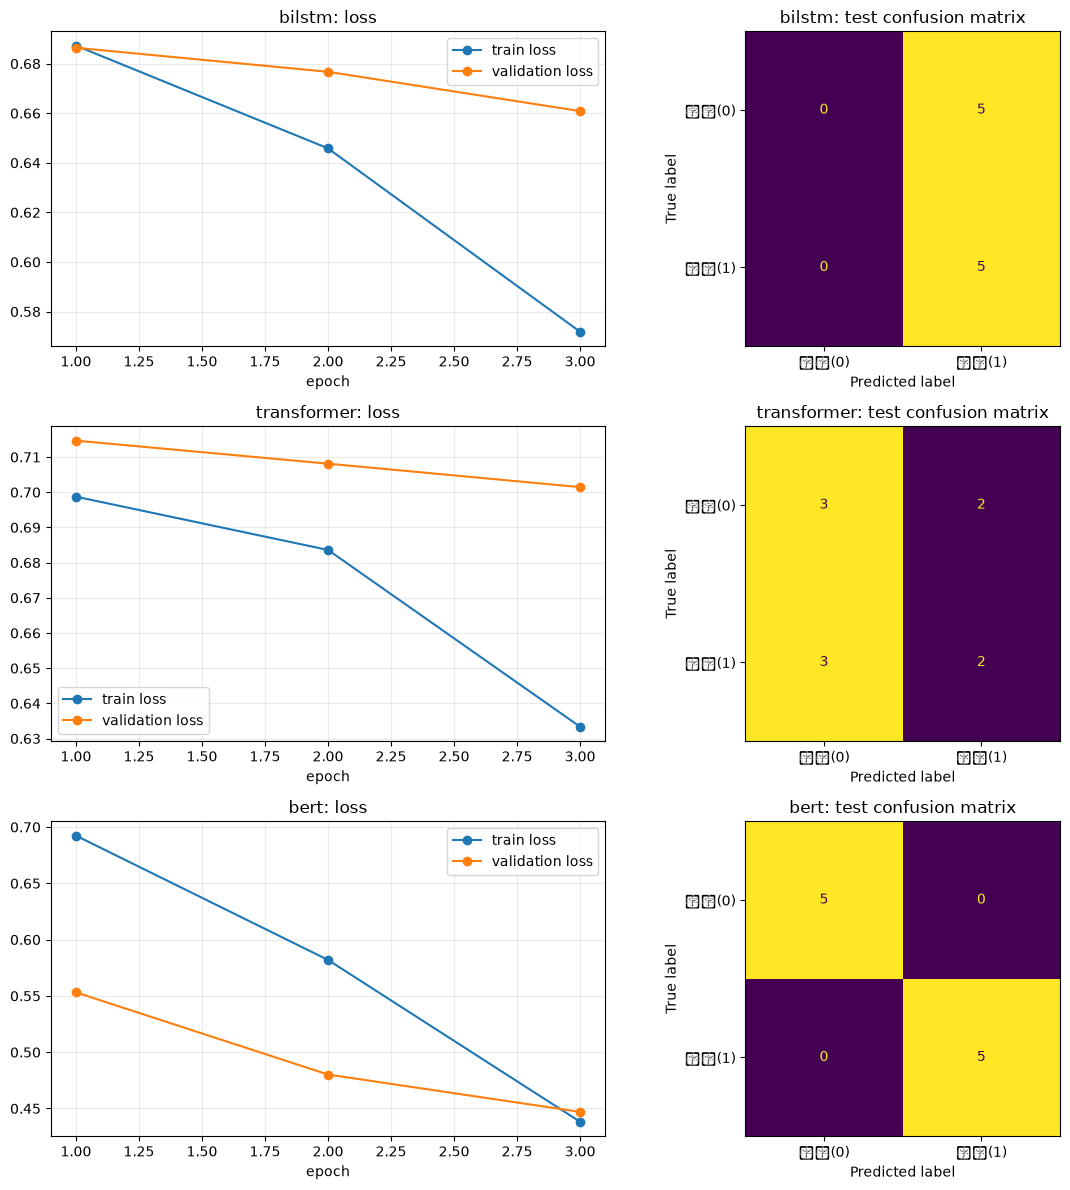

In [21]:
if results:
    fig, axes = plt.subplots(
        len(results), 2, figsize=(12, 4 * len(results)), squeeze=False
    )
    for row, result in enumerate(results):
        history = pd.DataFrame(result["history"])
        axes[row, 0].plot(history["epoch"], history["train_loss"],
                          marker="o", label="train loss")
        axes[row, 0].plot(history["epoch"], history["val_loss"],
                          marker="o", label="validation loss")
        axes[row, 0].set_title(f"{result['model']}: loss")
        axes[row, 0].set_xlabel("epoch")
        axes[row, 0].legend()
        axes[row, 0].grid(alpha=0.25)

        matrix = np.asarray(result["test_metrics"]["confusion_matrix"])
        ConfusionMatrixDisplay(
            matrix, display_labels=["正常(0)", "不良(1)"]
        ).plot(ax=axes[row, 1], colorbar=False)
        axes[row, 1].set_title(f"{result['model']}: test confusion matrix")
    plt.tight_layout()
    plt.savefig(output_root / "model_comparison.png", dpi=200,
                bbox_inches="tight")
    plt.show()


### 13.2 如何解释结果

请按以下顺序解释，而不是只宣布“哪个模型最高”：

1. **先看数据边界**：当前是演示数据还是真实数据？测试集是否独立？
2. **再看错误类型**：假阳性会误伤正常内容，假阴性会漏掉不良内容，两者代价可能不同；
3. **比较架构**：BiLSTM 与随机 Transformer 的差异更接近架构影响；
4. **比较预训练**：随机 Transformer 与 BERT 的差异同时包含预训练、分词器和模型规模影响，不能只归因于某一个因素；
5. **检查稳定性**：一次划分、一个随机种子的差异可能只是偶然波动；
6. **考虑成本**：准确率提升是否值得更高的显存、推理延迟和部署复杂度？

### 本次实验结论（运行后填写）

- 数据版本与规模：
- 最佳验证指标及对应模型：
- 测试集主要错误：
- 与预期一致或不一致之处：
- 不能从本实验推出的结论：


## 14. 实验日志：记录过程，不只记录最好结果

每完成一次有实质意义的尝试，就复制下面一行并填写。失败实验同样要记录，因为它解释了为什么最终参数是现在这样。

| 日期时间 | 数据版本/哈希 | 模型与参数 | 改动原因 | 观察结果 | 失败或异常 | 下一步决策 |
|---|---|---|---|---|---|---|
| 2026-07-28 | 内置演示数据 | 默认参数 | 验证完整代码链路 | 运行后填写 | 运行后填写 | 换用真实数据 |

建议额外记录：Git 提交号、随机种子、运行设备、耗时、峰值显存以及输出目录。不要只保留最终最好的一组参数。


## 15. 从 Notebook 走向可重复流水线

当前结构已经为自动化保留了接口：

- 所有可变参数集中在顶部 `parameters` 单元格；
- 数据清洗、划分、训练、评价和保存都由函数完成；
- 关键中间结果和模型写入 `OUTPUT_ROOT`；
- 可用 Papermill 非交互执行：

```bash
papermill week4_rnn_transformer_bert.ipynb runs/seed_42.ipynb \
  -p DATA_PATH data/train.csv -p SEED 42 -p EPOCHS 5
```

若实验扩展到多个数据集、模型和随机种子，应把通用模型代码移入 `src/` 模块，把数据准备、训练和分析拆成多个较小 Notebook，再用 Makefile、Snakemake 或 CI 连接。每次提交前至少执行一次“Restart Kernel and Run All”，确认没有依赖隐藏状态。


## 16. 版本控制、共享与长期可读性

建议的最小仓库结构：

```text
project/
├── README.md
├── requirements.txt
├── notebooks/week4_rnn_transformer_bert.ipynb
├── data/sample.csv
├── outputs/
└── src/
```

- 使用 Git 保存演进过程，并在提交前清理不必要的大型输出；
- 使用 `nbdime config-git --enable --global` 获得结构化 Notebook 差异；
- 可用 `jupyter nbconvert --to html ...` 保存静态 HTML 档案；
- 公开分享时附 README、数据说明、宽松许可证与环境文件；
- 敏感数据不能公开时，提供匿名化小样本、字段字典、处理代码和访问条件；
- 需要无安装运行时，可进一步配置 Binder 或 Docker。


## 17. 依赖与运行清单

最后输出关键依赖版本和本次参数，并保存为 JSON。即使 Notebook 脱离原环境，这些信息也能帮助未来重建环境。


In [22]:
packages = [
    "torch", "transformers", "scikit-learn",
    "numpy", "pandas", "matplotlib", "jupyterlab",
]

def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return "not installed"


manifest = {
    "author": AUTHOR,
    "author_contact": AUTHOR_CONTACT,
    "lab_code_contact": LAB_CODE_CONTACT,
    "python": sys.version,
    "device": str(device),
    "packages": {name: installed_version(name) for name in packages},
    "parameters": {
        "data_path": DATA_PATH,
        "models_to_run": MODELS_TO_RUN,
        "seed": SEED,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "base_lr": BASE_LR,
        "bert_lr": BERT_LR,
        "bert_model": BERT_MODEL,
    },
}
save_json(output_root / "run_manifest.json", manifest)
display(pd.DataFrame(
    manifest["packages"].items(), columns=["dependency", "version"]
))
print(json.dumps(manifest["parameters"], ensure_ascii=False, indent=2))


,dependency,version
0,torch,2.13.0+cu132
1,transformers,5.14.1
2,scikit-learn,1.9.0
3,numpy,2.5.0
4,pandas,3.0.3
5,matplotlib,3.11.0
6,jupyterlab,4.6.1


{
  "data_path": null,
  "models_to_run": [
    "bilstm",
    "transformer",
    "bert"
  ],
  "seed": 42,
  "epochs": 3,
  "batch_size": 16,
  "max_length": 128,
  "base_lr": 0.001,
  "bert_lr": 2e-05,
  "bert_model": "google-bert/bert-base-chinese"
}


## 18. 结语：这条模型演进路线意味着什么

这项训练的价值不在于记住三个类的写法，而在于建立一个清晰的因果比较框架：

- BiLSTM 展示递归序列建模；
- 随机 Transformer 展示自注意力架构；
- BERT 展示预训练表示对下游任务的迁移。

当三者使用同一数据划分和评价框架时，我们才开始有条件讨论架构、预训练、成本与错误类型之间的关系。下一步不应继续在演示样本上调参，而应换成定义清晰、规模合理的真实数据集，增加多随机种子实验、误差分析、分布外测试和效率指标。

对提示注入检测研究而言，这份 Notebook 可作为**文本级二分类基线**，但提示注入并不等同于普通不良信息。后续应把任务扩展到未知攻击泛化、注入片段定位、RAG/Agent 上下文中的间接注入，以及“控制意图—实际行为”一致性检测。
